In [11]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# **CONFIG**

In [2]:
DATA_DIR = "/kaggle/input/indian-currency-real-vs-fake-notes-dataset/data/data"
BASE_MODEL_PATH = "/kaggle/input/feature-enhancements-model/keras/default/1/fine_tuned_base_model.keras"
SAVE_PATH = "/kaggle/working/attention_enhanced_model.keras"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10
RANDOM_STATE = 42

# **DATA LOADING**

In [3]:
def load_images(folder, label):
    images, labels = [], []
    for subdir in os.listdir(folder):
        sub_path = os.path.join(folder, subdir)
        if not os.path.isdir(sub_path):
            continue
        for file in tqdm(os.listdir(sub_path), desc=f"Loading {subdir}"):
            img_path = os.path.join(sub_path, file)
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.resize(img, IMG_SIZE)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            images.append(img)
            labels.append(label)
    return np.array(images), np.array(labels)

real_imgs, real_lbls = load_images(os.path.join(DATA_DIR, "real"), 1)
fake_imgs, fake_lbls = load_images(os.path.join(DATA_DIR, "fake"), 0)

X = np.concatenate([real_imgs, fake_imgs])
y = np.concatenate([real_lbls, fake_lbls])

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y)
print(f"Dataset ready: Train={len(X_train)} | Validation={len(X_val)}")

Loading 100: 100%|██████████| 380/380 [00:03<00:00, 107.63it/s]


Dataset ready: Train=5956 | Validation=1489


In [4]:
def make_dataset(images, labels, train=True):
    ds = tf.data.Dataset.from_tensor_slices((images, labels))
    ds = ds.map(lambda x, y: (tf.cast(x, tf.float32)/255.0, tf.cast(y, tf.int32)),
                num_parallel_calls=tf.data.AUTOTUNE)
    if train:
        ds = ds.shuffle(1024).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    else:
        ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(X_train, y_train)
val_ds = make_dataset(X_val, y_val, train=False)

I0000 00:00:1760776815.990369      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1760776815.991101      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


# **CBAM BLOCK**

In [8]:
def cbam_block_keras(input_feature, ratio=8):
    """CBAM block compatible with Keras Functional API"""
    channel = input_feature.shape[-1]

    # Channel Attention
    avg_pool = GlobalAveragePooling2D()(input_feature)
    avg_pool = Reshape((1, 1, channel))(avg_pool)
    max_pool = GlobalMaxPooling2D()(input_feature)
    max_pool = Reshape((1, 1, channel))(max_pool)

    shared_dense_one = Dense(channel // ratio, activation='relu', kernel_initializer='he_normal', use_bias=True)
    shared_dense_two = Dense(channel, kernel_initializer='he_normal', use_bias=True)

    avg_out = shared_dense_two(shared_dense_one(avg_pool))
    max_out = shared_dense_two(shared_dense_one(max_pool))
    channel_attention = Activation('sigmoid')(Add()([avg_out, max_out]))
    x = Multiply()([input_feature, channel_attention])

    # Spatial Attention
    avg_pool_spatial = Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True),
                              output_shape=lambda s: (s[0], s[1], s[2], 1))(x)
    max_pool_spatial = Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True),
                              output_shape=lambda s: (s[0], s[1], s[2], 1))(x)
    concat = Concatenate(axis=-1)([avg_pool_spatial, max_pool_spatial])
    spatial_attention = Conv2D(1, kernel_size=7, padding='same', activation='sigmoid', kernel_initializer='he_normal')(concat)
    x = Multiply()([x, spatial_attention])

    return x



# **LOAD BASE MODEL**

In [9]:
base_model = load_model(BASE_MODEL_PATH, safe_mode=False)
base_model.trainable = True

# Find the last convolutional layer automatically
conv_layer = None
for layer in reversed(base_model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        conv_layer = layer
        break

if conv_layer is None:
    raise RuntimeError("Could not find a 4D convolutional feature map in the base model. "
                       "Ensure the base model has Conv2D layers.")

print(f"Using last conv layer: {conv_layer.name}")

feature_map = conv_layer.output


Using last conv layer: Conv_1


# **ATTENTION ENHANCEMENT**

In [12]:
x = cbam_block_keras(feature_map)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

attention_model = Model(inputs=base_model.input, outputs=output)

attention_model.compile(optimizer=Adam(1e-5), loss='binary_crossentropy', metrics=['accuracy'])
attention_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,828,100 (10.79 MB)

 Trainable params: 2,414,852 (9.21 MB)

 Non-trainable params: 413,248 (1.58 MB)

# **callbacks**

In [13]:
callbacks = [
    EarlyStopping(patience=4, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.2, patience=2),
    ModelCheckpoint(SAVE_PATH, save_best_only=True)
]

# **TRAINING**

In [14]:
history = attention_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10


I0000 00:00:1760777212.958985      98 service.cc:148] XLA service 0x7fecc81152f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1760777212.959939      98 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1760777212.959957      98 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1760777214.205223      98 cuda_dnn.cc:529] Loaded cuDNN version 90300


  3/187 ━━━━━━━━━━━━━━━━━━━━ 11s 65ms/step - accuracy: 0.5955 - loss: 0.6778 

I0000 00:00:1760777222.017328      98 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


187/187 ━━━━━━━━━━━━━━━━━━━━ 44s 123ms/step - accuracy: 0.8372 - loss: 0.3782 - val_accuracy: 0.9308 - val_loss: 0.1678 - learning_rate: 1.0000e-05
Epoch 2/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.9620 - loss: 0.0977 - val_accuracy: 0.9805 - val_loss: 0.0618 - learning_rate: 1.0000e-05
Epoch 3/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.9772 - loss: 0.0603 - val_accuracy: 0.9859 - val_loss: 0.0467 - learning_rate: 1.0000e-05
Epoch 4/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.9892 - loss: 0.0337 - val_accuracy: 0.9886 - val_loss: 0.0360 - learning_rate: 1.0000e-05
Epoch 5/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.9907 - loss: 0.0283 - val_accuracy: 0.9906 - val_loss: 0.0352 - learning_rate: 1.0000e-05
Epoch 6/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.9921 - loss: 0.0207 - val_accuracy: 0.9906 - val_loss: 0.0302 - learning_rate: 1.0000e-05
Epoch 7/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - accurac

In [15]:
attention_model.save(SAVE_PATH)

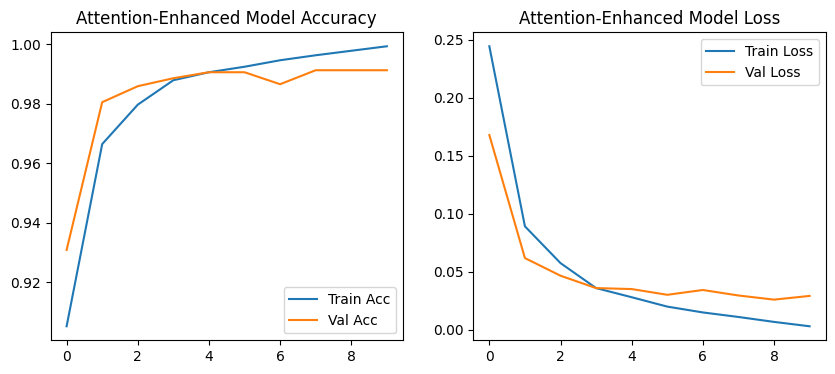

In [16]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Attention-Enhanced Model Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Attention-Enhanced Model Loss')
plt.legend()
plt.show()

In [17]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# Predict probabilities
y_pred_prob = attention_model.predict(val_ds)
y_pred = (y_pred_prob > 0.5).astype(int)

# True labels
y_true = np.concatenate([y for x, y in val_ds], axis=0)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

# Classification report: precision, recall, f1-score
report = classification_report(y_true, y_pred, target_names=["Fake", "Real"])
print("Classification Report:\n", report)

# ROC-AUC score
auc = roc_auc_score(y_true, y_pred_prob)
print("ROC-AUC Score:", auc)

47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 100ms/step
Confusion Matrix:
 [[496   6]
 [  7 980]]
Classification Report:
               precision    recall  f1-score   support

        Fake       0.99      0.99      0.99       502
        Real       0.99      0.99      0.99       987

    accuracy                           0.99      1489
   macro avg       0.99      0.99      0.99      1489
weighted avg       0.99      0.99      0.99      1489

ROC-AUC Score: 0.9992270028296137
